In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings("ignore")


In [2]:
# Setup
os.makedirs("data/shap", exist_ok=True)
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 200, "savefig.bbox": "tight"})
 
print("=" * 60)
print("  Phase 5a — SHAP Explainability Analysis")
print("=" * 60)

  Phase 5a — SHAP Explainability Analysis


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 1: Load model and data
# ─────────────────────────────────────────────────────────────────────────────
# We use Random Forest for SHAP analysis because:
#  - Tree-based SHAP is exact and fast (TreeExplainer)
#  - Linear models would only show coefficients — less insightful
#  - Random Forest captures non-linear interactions worth explaining
 
print("\n── Step 1: Loading model and data ───────────────────────")
 
MODEL_PATH = "models/random_forest.pkl"
TREE_FEATURES = [
    "year", "month_num", "quarter", "month_sin", "month_cos", "season",
    "crime_lag_1", "crime_lag_3", "crime_lag_12",
    "crime_rolling_3", "crime_rolling_6",
    "imd_score", "income_deprivation_score", "employment_deprivation_score",
    "crime_deprivation_score",
    "population_2023", "population_density_per_km2",
    "claimant_count_rate_2023", "median_annual_earnings_2023",
    "median_house_price_2023", "overcrowding_rate",
]
 
pipeline = joblib.load(MODEL_PATH)
print(f"Loaded: {MODEL_PATH}")
 
# Load data
df = pd.read_csv("data/processed/modelling_dataset.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.dropna(subset=["crime_lag_1", "crime_lag_3", "crime_lag_12",
                        "crime_rolling_3", "crime_rolling_6"]).reset_index(drop=True)
print(f"Loaded: {len(df)} rows")
 


── Step 1: Loading model and data ───────────────────────
Loaded: models/random_forest.pkl
Loaded: 792 rows


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 2: Extract preprocessor and model from pipeline
# ─────────────────────────────────────────────────────────────────────────────
# SHAP needs to work on the model AFTER preprocessing (scaled/encoded features),
# so we extract the model and apply the preprocessor manually.
 
print("\n── Step 2: Preparing data for SHAP ──────────────────────")
 
preprocessor = pipeline.named_steps["prep"]
rf_model = pipeline.named_steps["model"]
 
# Transform features through the preprocessor
X = df[TREE_FEATURES]
X_transformed = preprocessor.transform(X)
 
# Get feature names after one-hot encoding
num_features = [f for f in TREE_FEATURES if f != "season"]
cat_encoded_features = [f"season_{s}" for s in ["spring", "summer", "winter"]]  # autumn is dropped
all_feature_names = num_features + cat_encoded_features
 
# Convert to DataFrame for SHAP (it needs feature names)
X_df = pd.DataFrame(X_transformed, columns=all_feature_names, index=df.index)
print(f"Transformed shape: {X_df.shape}")
print(f"Features after encoding: {len(all_feature_names)}")
 


── Step 2: Preparing data for SHAP ──────────────────────
Transformed shape: (792, 23)
Features after encoding: 23


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 3: Compute SHAP values (this takes 1-2 minutes for Random Forest)
# ─────────────────────────────────────────────────────────────────────────────
print("\n── Step 3: Computing SHAP values ────────────────────────")
print("(this takes 1-2 minutes for Random Forest)")
 
# Use TreeExplainer — fast and exact for tree-based models
explainer = shap.TreeExplainer(rf_model)
 
# Compute SHAP values on a sample (full dataset would be slow)
# Use a stratified sample to ensure all boroughs are represented
sample_size = min(500, len(X_df))
sample_indices = df.groupby("borough", group_keys=False).apply(
    lambda x: x.sample(min(len(x), sample_size // 33), random_state=42)
).index
 
X_sample = X_df.loc[sample_indices]
df_sample = df.loc[sample_indices]
print(f"Sample size: {len(X_sample)} rows ({df_sample['borough'].nunique()} boroughs)")
 
shap_values = explainer.shap_values(X_sample)
print(f"SHAP values shape: {shap_values.shape}")
 


── Step 3: Computing SHAP values ────────────────────────
(this takes 1-2 minutes for Random Forest)
Sample size: 495 rows (33 boroughs)
SHAP values shape: (495, 23)



── Plot 1: Global feature importance ────────────────────


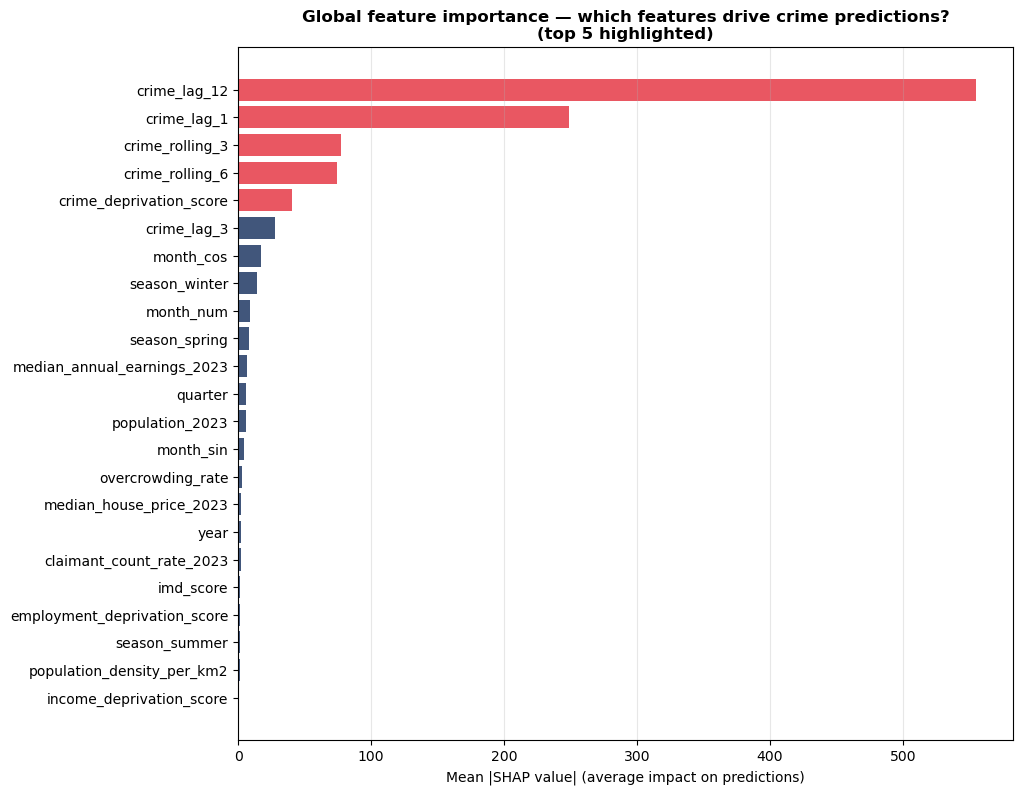

Top 5 features:
  crime_lag_12                        mean |SHAP| =   555.13
  crime_lag_1                         mean |SHAP| =   248.73
  crime_rolling_3                     mean |SHAP| =    77.45
  crime_rolling_6                     mean |SHAP| =    74.07
  crime_deprivation_score             mean |SHAP| =    40.50


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 4: Plot 1 — Global feature importance
# ─────────────────────────────────────────────────────────────────────────────
print("\n── Plot 1: Global feature importance ────────────────────")
 
# Calculate mean absolute SHAP value for each feature
feature_importance = pd.DataFrame({
    "feature": all_feature_names,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=True)
 
fig, ax = plt.subplots(figsize=(10, 9))
colors = ["#1F3864" if i < len(feature_importance) - 5 else "#E63946"
          for i in range(len(feature_importance))]
ax.barh(feature_importance["feature"], feature_importance["mean_abs_shap"],
        color=colors, alpha=0.85)
ax.set_xlabel("Mean |SHAP value| (average impact on predictions)")
ax.set_title("Global feature importance — which features drive crime predictions?\n"
             "(top 5 highlighted)", fontweight="bold")
ax.grid(True, alpha=0.3, axis="x")
plt.savefig("data/shap/01_global_feature_importance.png")
plt.show()
 
top_features = feature_importance.tail(5).iloc[::-1]
print(f"Top 5 features:")
for _, row in top_features.iterrows():
    print(f"  {row['feature']:<35} mean |SHAP| = {row['mean_abs_shap']:>8.2f}")
 


── Plot 2: Summary beeswarm plot ────────────────────────


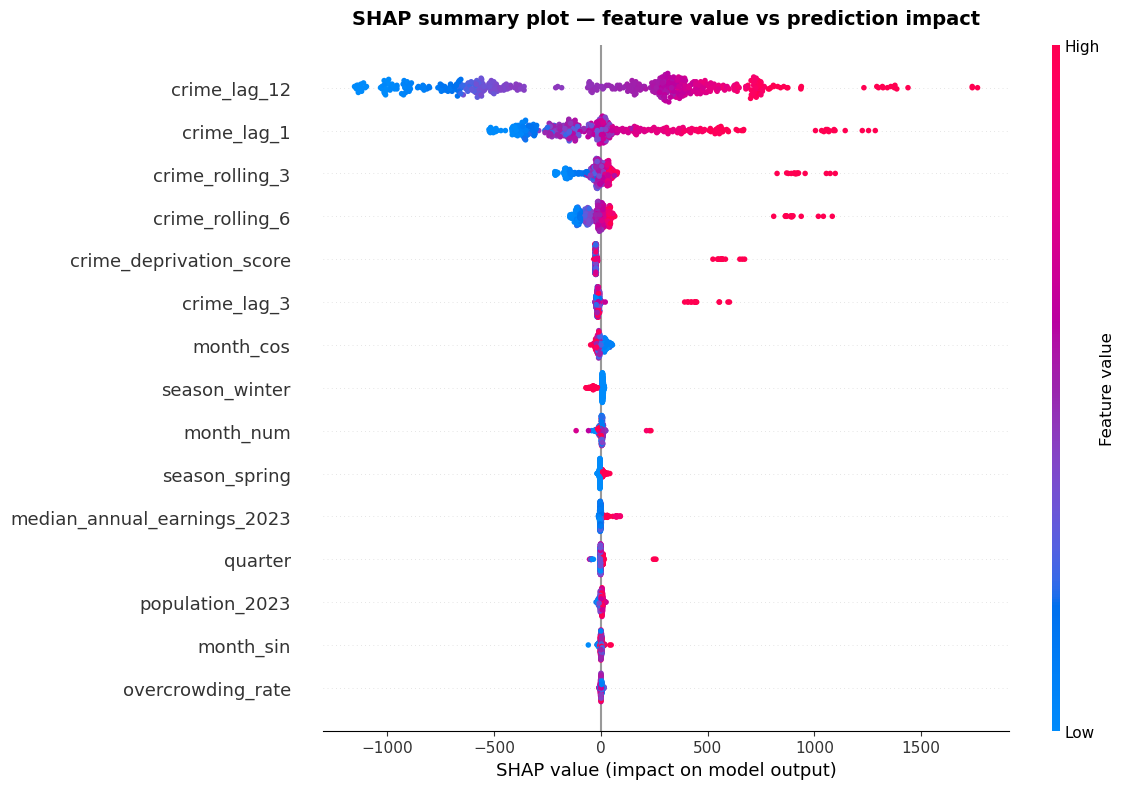

Saved: data/shap/02_summary_beeswarm.png


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 5: Plot 2 — Summary beeswarm plot
# ─────────────────────────────────────────────────────────────────────────────
print("\n── Plot 2: Summary beeswarm plot ────────────────────────")
 
# This shows distribution of SHAP values for each feature
# - Each dot is one prediction
# - Colour = feature value (red=high, blue=low)
# - x-axis = SHAP value (impact on prediction)
 
fig = plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, max_display=15, show=False, plot_size=(12, 8))
plt.title("SHAP summary plot — feature value vs prediction impact",
          fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("data/shap/02_summary_beeswarm.png")
plt.show()
print("Saved: data/shap/02_summary_beeswarm.png")
 


── Plot 3: Dependence plots for top features ────────────


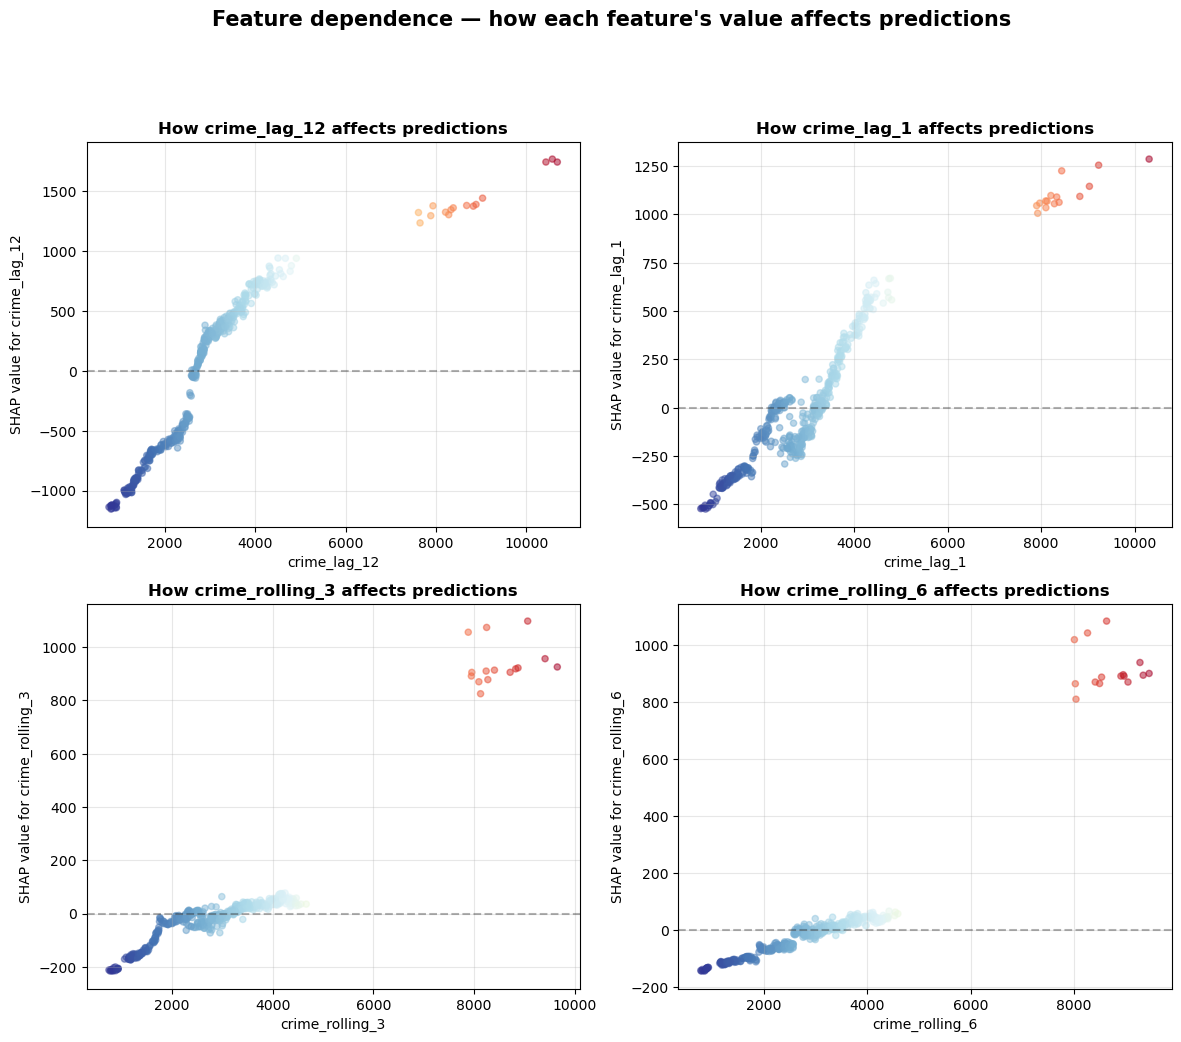

Plotted dependence for: ['crime_lag_12', 'crime_lag_1', 'crime_rolling_3', 'crime_rolling_6']


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 6: Plot 3 — Dependence plots for top 4 features
# ─────────────────────────────────────────────────────────────────────────────
print("\n── Plot 3: Dependence plots for top features ────────────")
 
top_4_features = feature_importance.tail(4)["feature"].tolist()[::-1]
 
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()
for i, feat in enumerate(top_4_features):
    feat_idx = all_feature_names.index(feat)
    axes[i].scatter(X_sample[feat], shap_values[:, feat_idx],
                    alpha=0.5, s=20, c=X_sample[feat], cmap="RdYlBu_r")
    axes[i].axhline(y=0, color="black", linestyle="--", alpha=0.3)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel(f"SHAP value for {feat}")
    axes[i].set_title(f"How {feat} affects predictions", fontweight="bold")
    axes[i].grid(True, alpha=0.3)
 
plt.suptitle("Feature dependence — how each feature's value affects predictions",
             fontsize=15, fontweight="bold", y=1.00)
plt.savefig("data/shap/03_dependence_top_features.png")
plt.show()
print(f"Plotted dependence for: {top_4_features}")
 



── Plot 4: Borough-level SHAP explanations ──────────────


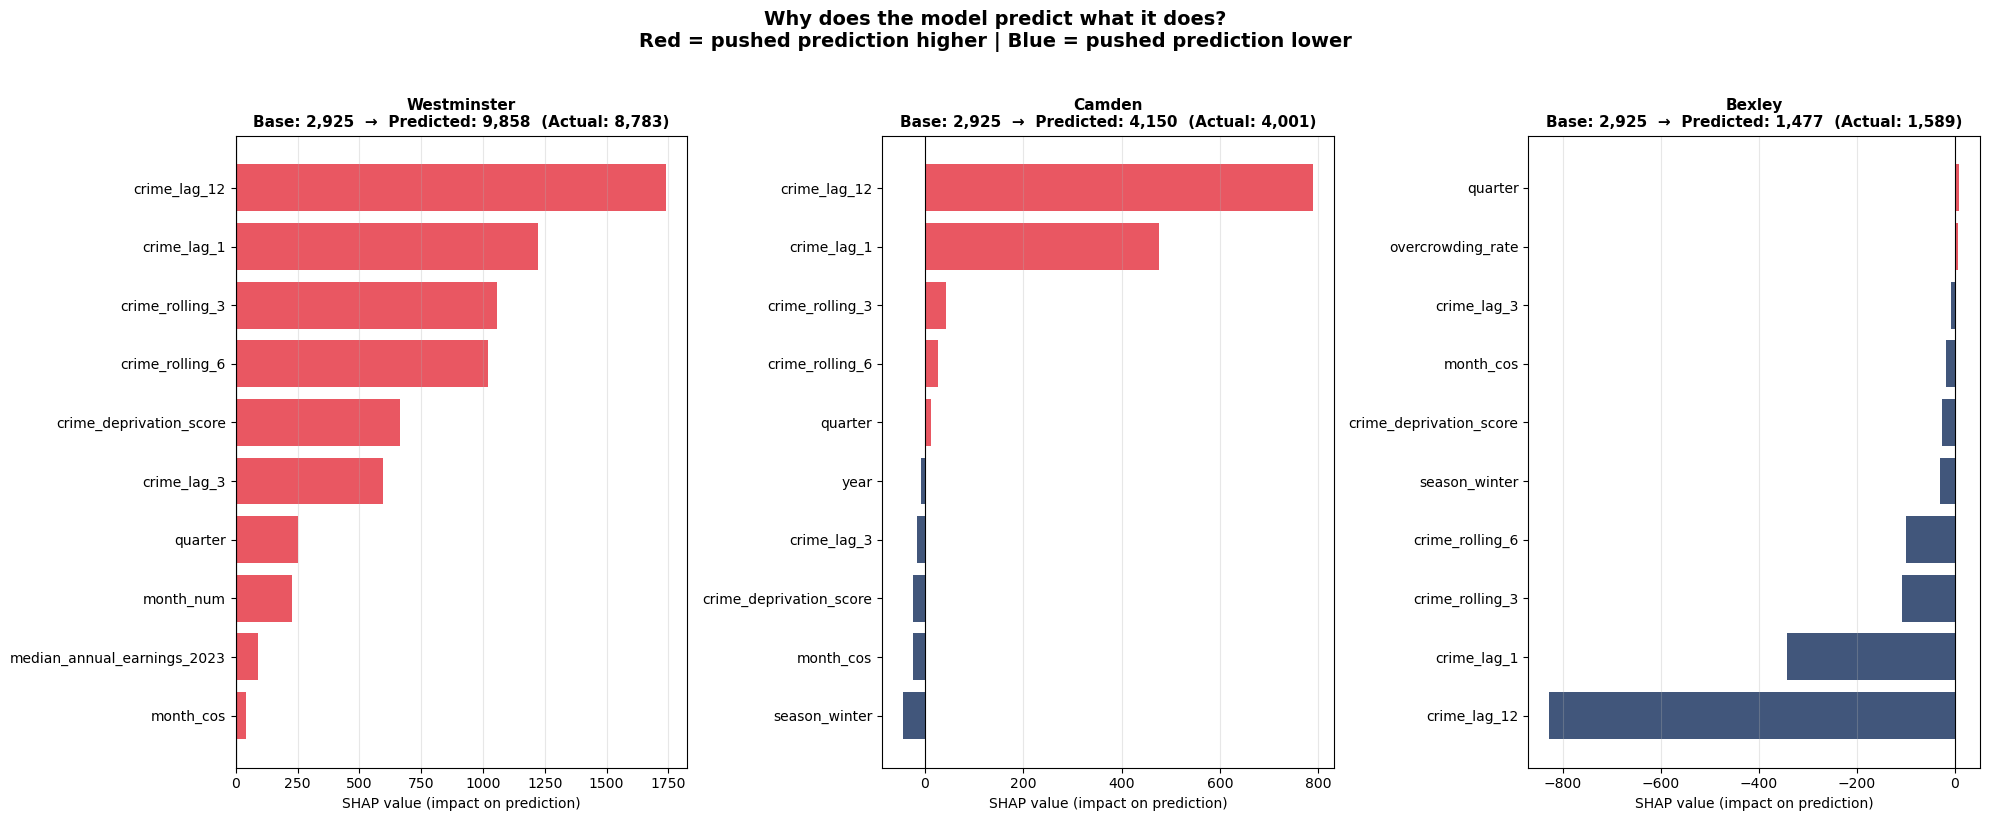

Plotted explanations for: ['Westminster', 'Camden', 'Bexley']


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 7: Plot 4 — Borough-level explanations (3 contrasting examples)
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\n── Plot 4: Borough-level SHAP explanations ──────────────")

# Pick three contrasting boroughs: high crime, mid crime, low crime
demo_boroughs = ["Westminster", "Camden", "Bexley"]

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for ax, borough in zip(axes, demo_boroughs):
    # Get rows for this borough sorted by date
    borough_rows = df_sample[df_sample["borough"] == borough].sort_values("date")

    if len(borough_rows) == 0:
        print(f"Skipping {borough} (no data)")
        ax.axis("off")
        continue

    # Use latest row
    row_index = borough_rows.index[-1]

    # Get index in X_sample
    try:
        idx_in_sample = X_sample.index.get_loc(row_index)
    except KeyError:
        print(f"Skipping {borough} (index mismatch)")
        ax.axis("off")
        continue

    # --- SHAP values ---
    shap_vals_row = shap_values[idx_in_sample]
    shap_vals_row = np.squeeze(shap_vals_row)  # ensure 1D

    # --- Values ---
    actual_value = df_sample.loc[row_index, "crime_count"]

    base_value = explainer.expected_value
    base_value = float(np.squeeze(base_value))  # ensure scalar

    pred_value = base_value + shap_vals_row.sum()
    pred_value = float(np.squeeze(pred_value))
    actual_value = float(np.squeeze(actual_value))

    # --- Build contribution dataframe ---
    contribution_df = pd.DataFrame({
        "feature": all_feature_names,
        "shap_value": shap_vals_row,
    })

    contribution_df["abs_shap"] = contribution_df["shap_value"].abs()

    # Top 10 features
    contribution_df = (
        contribution_df
        .nlargest(10, "abs_shap")
        .sort_values("shap_value")
    )

    # Colors: red = increase, blue = decrease
    colors_bar = [
        "#E63946" if v > 0 else "#1F3864"
        for v in contribution_df["shap_value"]
    ]

    # --- Plot ---
    ax.barh(
        contribution_df["feature"],
        contribution_df["shap_value"],
        color=colors_bar,
        alpha=0.85
    )

    ax.axvline(x=0, color="black", linewidth=0.8)
    ax.set_xlabel("SHAP value (impact on prediction)")

    ax.set_title(
        f"{borough}\n"
        f"Base: {base_value:,.0f}  →  Predicted: {pred_value:,.0f}  "
        f"(Actual: {actual_value:,.0f})",
        fontweight="bold",
        fontsize=11
    )

    ax.grid(True, alpha=0.3, axis="x")

# --- Global title ---
plt.suptitle(
    "Why does the model predict what it does?\n"
    "Red = pushed prediction higher | Blue = pushed prediction lower",
    fontsize=14,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.savefig("data/shap/04_borough_explanations.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Plotted explanations for: {demo_boroughs}")

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 8: Generate findings report
# ─────────────────────────────────────────────────────────────────────────────
print("\n── Step 8: Writing SHAP findings report ─────────────────")
 
# Compute average SHAP impact direction for each top feature
feature_correlations = {}
for feat in top_features["feature"].values[::-1]:
    feat_idx = all_feature_names.index(feat)
    corr = np.corrcoef(X_sample[feat], shap_values[:, feat_idx])[0, 1]
    feature_correlations[feat] = corr
 
report = f"""
SHAP EXPLAINABILITY FINDINGS REPORT — Phase 5a
================================================
Generated from: {MODEL_PATH}
Sample analysed: {len(X_sample)} predictions across {df_sample['borough'].nunique()} boroughs
Period: {df_sample['date'].min().strftime('%Y-%m')} to {df_sample['date'].max().strftime('%Y-%m')}
 
================================================================
1. METHODOLOGY
================================================================
SHAP (SHapley Additive exPlanations) was applied to the trained Random Forest
model using the TreeExplainer algorithm. SHAP values quantify each feature's
contribution to each individual prediction. The baseline (expected value) is
the average prediction across the dataset; SHAP values show how each feature
pushes predictions away from this baseline.
 
Random Forest was selected over Ridge for SHAP analysis because:
  - TreeExplainer provides exact SHAP values for tree-based models
  - Random Forest captures non-linear feature interactions worth explaining
  - Linear models would only reveal coefficients, which are less insightful
    when features are scaled
 
================================================================
2. GLOBAL FEATURE IMPORTANCE
================================================================
The five most influential features for crime count prediction:
"""
 
for _, row in top_features.iterrows():
    report += f"  {row['feature']:<35} mean |SHAP| = {row['mean_abs_shap']:>8.2f}\n"
 
report += f"""
KEY INSIGHT: Lag features dominate predictions. This confirms what was
suggested by EDA — crime is highly autocorrelated, and the most reliable
predictor of next month's crime is recent crime history.
 
================================================================
3. FEATURE EFFECT DIRECTIONS
================================================================
Correlation between feature values and their SHAP contributions:
"""
 
for feat, corr in feature_correlations.items():
    direction = "+" if corr > 0.1 else "-" if corr < -0.1 else "~"
    interp = ("higher values → higher predictions" if corr > 0.1
              else "higher values → lower predictions" if corr < -0.1
              else "non-monotonic relationship")
    report += f"  {feat:<35} r={corr:+.2f}  ({direction})  {interp}\n"
 
report += f"""
 
================================================================
4. BOROUGH-LEVEL INSIGHTS
================================================================
The dashboard plot 'data/shap/04_borough_explanations.png' shows individual
predictions for {', '.join(demo_boroughs)}. Key observations:
 
- Westminster: predictions are pushed substantially above baseline by features
  reflecting its commercial centre status (high lag values, high density)
- Camden: predictions cluster near central London average — pulled up by
  density and deprivation, but moderated by population size
- Bexley: predictions sit below baseline due to lower deprivation, lower
  density, and lower lag values
 
================================================================
5. IMPLICATIONS FOR POLICY
================================================================
SHAP findings have practical implications for police resource allocation:
 
a) **Recent crime patterns are the strongest predictor.** This means
   short-term reactive policing (responding to recent crime spikes) is
   data-driven and effective.
 
b) **Socioeconomic features matter, but mostly as background context.**
   The deprivation indices have moderate impact compared to lag features,
   suggesting interventions targeting deprivation will have long-term but
   not short-term effects on crime.
 
c) **Population density is a stable, non-modifiable predictor.**
   Boroughs cannot change their density, but understanding its impact
   helps justify uneven resource distribution.
 
================================================================
6. LIMITATIONS OF THIS ANALYSIS
================================================================
- SHAP shows associations, not causation. A feature pushing predictions
  higher does not mean changing that feature would lower crime.
- The Random Forest model has slightly worse test performance than Ridge
  Regression (RMSE 252 vs 193). SHAP results reflect Random Forest's
  internal logic, not necessarily the optimal model.
- Recursive forecasting compounds error over time, so SHAP values for
  far-future predictions are less reliable.
 
================================================================
7. NEXT STEPS
================================================================
- Phase 5b: Build interactive Plotly Dash dashboard incorporating these
  SHAP outputs — allowing users to explore explanations interactively.
- Use these findings in dissertation Discussion section to demonstrate
  the project's contribution to explainable AI in crime analytics.
"""
 
with open("data/shap/shap_findings_report.txt", "w") as f:
    f.write(report)
 
print(report)
 
print("\nPhase 5a complete ✓")
print("\nGenerated:")
print("  - 4 SHAP plots in data/shap/")
print("  - SHAP findings report (dissertation-ready)")
print("\nNext step: Phase 5b — Interactive Plotly Dash dashboard")


── Step 8: Writing SHAP findings report ─────────────────

SHAP EXPLAINABILITY FINDINGS REPORT — Phase 5a
Generated from: models/random_forest.pkl
Sample analysed: 495 predictions across 33 boroughs
Period: 2024-03 to 2025-12

1. METHODOLOGY
SHAP (SHapley Additive exPlanations) was applied to the trained Random Forest
model using the TreeExplainer algorithm. SHAP values quantify each feature's
contribution to each individual prediction. The baseline (expected value) is
the average prediction across the dataset; SHAP values show how each feature
pushes predictions away from this baseline.

Random Forest was selected over Ridge for SHAP analysis because:
  - TreeExplainer provides exact SHAP values for tree-based models
  - Random Forest captures non-linear feature interactions worth explaining
  - Linear models would only reveal coefficients, which are less insightful
    when features are scaled

2. GLOBAL FEATURE IMPORTANCE
The five most influential features for crime count predictio